# PWM And Breathe Effects

Some notes to put my thoughts in order.

I'm trying to display an LED effect but instead of timings, I will use the interrupts generated by the PWM wave itself to drive the timings.

## Some definitions, I guess

I'm using one of the timers on the EFR32BG22 (TIMER0). It has three output/compare channels, which is perfect to drive the three LED channels in the HW. Single-slope pwm is more than enough. I could switch to dual-slope, wich halves the PWM frequency (not an issue, as we are not anywhere near the limit) and reduces harmonics and has better EMI, but then again, we are using a low PWM freq.

This graph shows how the timer generates the PWM signal (section 19.3.3.9 of the manual)

![PWM Graph](img/PWMGraph.png)

A "cycle accurate" version is shown below. The timer counts from 0 up to TOP. When the count transitions from 0 to 1, the output is set to 1. When the count matches OC (output compare), the output is toggled. Finally, when we the count reaches TOP, the counter is reset to 0.

The overflow interrupt (triggered by the counter reaching TOP), is triggered in the next cycle after reaching TOP (so NOT when the count reaches TOP NOR when the count resets to 0, but on the next transition from 0 to 1). That's a bit counterintuitive, but whatever...

Similarly, the buffered updates of TOP and OC are triggered when the count switches from 0 to 1

Another side-effect, I guess, is that the period of the signal is TOP + 1 cycles, not TOP, and setting OC to TOP would toggle the output for one clock cycle (so duty cycle would be TOP / (TOP + 1) = 99.99% and not 100%). In order to get a DC of 100%, you have to set OC >= TOP + 1, so there's never a compare match.

And finally, if we update a buffered register during the overflow interrupt, changes will not affect the next PWM period, because the buffered update is triggered before (or at the same time) than the interrupt, so if you have set the OC to A and update to B in the overflow interrupt, then you have to go through an extra PWM period with OC at A, and when the timer hits TOP again, it will update the OC register.

![alt text](img/PWMCycleAccurate.png)

### Brightness Gamma Correction

Because brightness is not perceived linearly by the eye, we can apply gamma correction to get a response closer to the perceived one.

### Frequencies

The timer clock is 38.4 MHz. The PWM frequency is dictated by the TOP value. 

$$f_{pwm} = \frac{f_{clock}}{Preescaler * TOP + 1}$$

To play effects, we will use a lookup table. As long as we don't need to dynamically change it, we can precalculate it and store it in flash, and even if we have to use a dynamic table, it's 100s of B of RAM, so not a big deal, really.

Because it's the PWM wave driving the timing (to change brightness only at the rollover of the counter, using the buffered register), we will play each sample an integer number of times. if $T_{effect}$ is the period of the effect (time it takes to play all the samples of the LUT), then $T_{effect}$ must be divisible by $T_{pwm}$, or in other words, the period of the effect must always increments of $T_{pwm} * n_{samples}$ for everythin to stay in order.

$$T_{effect} = n_{samples} * T_{pwm} * n, where n > 0$$

$T_{effect}$ must increment in multiples of $n_{samples} * T_{pwm}$. For example, for a LUT of 200 samples and a PWM frequency of 1KHz, $T_{effect}$ would increase in 200ms increments.

### Interpolation

Because we have 32 bit registers and we are using one of the main timers of the chip (that is, driven by the High Freq clock), we can have a stupid level of resolution.

If we drive the PWM at 1kHz, the TOP value is 38400 (37399, really). So, while having enough samples of the effect in the LUT is enough to play it smoothly with very small increments of brightness, because we are going to have a bunch of pwm waves per sample, we can interpolate linearly their duty cycle and have them slowly increment from their intended value to the next one. Again, we have stupid resolution, let's use it.

### Brightness Lookup Calculation in Firmware

I wante to have the LUT calculated by the FW on startup, so it was more flexible, but looks like a lot of effort. The thing will never change, I'm not changing PWM freq on the fly, if ever! So having a pre-calculated table has more sense, as it can be stored in flash and that way be much bigger than what would be if stored in RAM. I'll leave the C code here in case I needed in the future

```C
/**
 * @brief Builds the Gamma-adjusted brighness lookup table.
 */
STATIC void buildGammaLookUpTable(const uint32_t maxValue) {
    // We will need this one to normalize the gamma curve from 0 to 1
    float maxGammaValue = pow((GAMMA_LUT_SIZE - 1), GAMMA_VALUE);
    for (uint32_t i = 0; i < GAMMA_LUT_SIZE; i++) {
        float aux = (pow(i, GAMMA_VALUE) / maxGammaValue);                 // returns a value normalised to 1
        gammaLookUp[i] = min(maxValue, (uint32_t)lround(aux * maxValue));  // gets the value relative to TOP
    }
    // DEBUG: print the table to check the values
    // for (uint32_t i = 0; i < GAMMA_LUT_SIZE; i++) {
    //     app_log_info("%" PRIu32 " -> Gamma-corrected %" PRIu32 "\r\n", i, gammaLookUp[i]);
    // }
}
```

{0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14

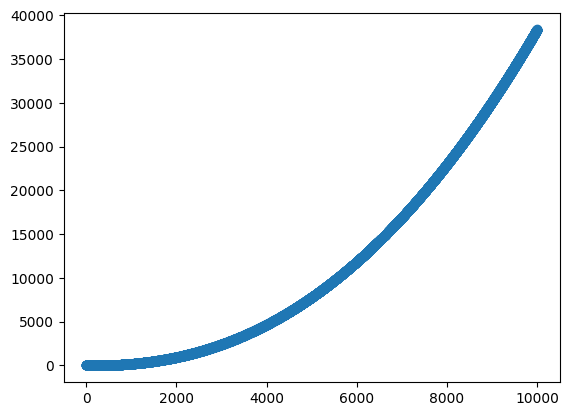

In [ ]:
# From HackADay - https://hackaday.com/2016/08/23/rgb-leds-how-to-master-gamma-and-hue-for-perfect-brightness/
## Creates a gamma-corrected lookup table
import math
import matplotlib.pyplot as plt

GAMMA = 2.3
STEPS = 10001
MAXBRIGHTNESS = 19200 # Max


def gamma(nsteps: int, gamma: float) -> list[float]:
    """Returns a list with a gamma-corrected curve of nsteps steps with values from 0 to 1.

    Args:
        nsteps (_type_): size of the list to return
        gamma (_type_): gamma coefficient

    Returns:
        list[float]: list of gamma corrected values from 0 to 1
    """
    gammaedUp = [math.pow(x, gamma) for x in range(nsteps)]
    return [x / max(gammaedUp) for x in gammaedUp]  # normalize from 0 to 1


def rounder(topValue: int, gammas: list[float]) -> list[int]:
    """Returns a rounded list of values mapped from 0 to topValue using the gamma-corrected curve passed as gammas

    Args:
        topValue (int): the value to map the max value of the gamma-curve
        gammas (list[float]): a normalized (0 to 1) list of values

    Returns:
        list[int]: a list of ints, with a curve from 0 to topValue, that will be gamma-corrected
    """
    return [min(topValue, round(x * topValue)) for x in gammas]


def buildGammaLUT(nsteps: int, gamma: float, maxBrightness: int) -> list[int]:
    """Builds the gamma-corrected birghtness lookup table

    Args:
        nsteps (int): size of the lookup table
        gamma (float): the gamma correction factor
        maxBrightness (int): max brightness of the table

    Returns:
        list[int]: a list with a gamma-corrected curve
    """
    LUT: list[int] = [0] * nsteps

    for i in range(nsteps):
        aux = math.pow(i, gamma) / math.pow((nsteps - 1), gamma)
        LUT[i] = min(maxBrightness, round(aux * maxBrightness))
    return LUT

def generateCHeader(length: int, gamma: float) -> str:
    """Generates a C Header implementing the gamma-corrected brightness Look Up

    Args:
        length (int): length of the table
        gamma (float): value of gamma

    Returns:
        str: a string containing a C header, ready to be pasted in a header file
    """
    return (
        f"/**\n"
        f" * @file brightnessLUT.h\n"
        f" * @author Joel Santos (jsantosrico@gmail.com)\n"
        f" * @brief Header containing the lookup table for gamma-corrected brightness\n"
        f" * @version 0.1\n"
        f" * @date 2026-02-11\n"
        f" *\n"
        f" * @copyright Copyright (c) 2026\n"
        f" *\n"
        f" * This header contains the look-up table for different brightness levels, given as an integer value representing a\n"
        f" * percentage with two decimal places (position 0 -> 0%, position 1234 ->12.34%)\n"
        f" *\n"
        f" * This allows us:\n"
        f" *\n"
        f" * - Having a big table (two decimal places, 10K positions). We have a lot of resolution on the compare value (32 bit\n"
        f" * counter) so it would be a shame not make use of it by just having 100 values.\n"
        f" * - It is precalculated and can be stored in flash and thus take no RAM at all!\n"
        f" *\n"
        f' * This file is generated from the code on the "PWM And Breathe Effect" jupyter notebook in /docs\n'
        f" *\n"
        f" */\n"
        f"\n"
        f"#ifndef _BRIGHTNESS_LUT_H_\n"
        f"#define _BRIGHTNESS_LUT_H_\n"
        f"\n"
        f"#include <inttypes.h>\n"
        f"\n"
        f"/**\n"
        f" * @brief Size of the gamma-corrected brightness look up table\n"
        f" */\n"
        f"#define GAMMA_LUT_SIZE {length}UL\n"
        f"\n"
        f"/**\n"
        f" * @brief Contains the gamma-corrected brightness values, mapping percentage with two decimal places (as a uint) to the\n"
        f" * compare register value required to obtain that perceived level of brightness\n"
        f" *\n"
        f" * Gamma-value -> {gamma:.1f}\n"
        f" *\n"
        f" */\n"
        f"extern const uint32_t brightnessLookUp[GAMMA_LUT_SIZE];\n"
        f"\n"
        f"#endif  // _BRIGHTNESS_LUT_H_\n"
    )

def generateCFile(lut: list[int]) -> str:
    """Generates a C file with the definition of the LUT

    Args:
        lut (list[int]): the LUT to get into an array

    Returns:
        str: a string containing a C header, ready to be pasted in a C file

    """
    lutAsString: str = ", ".join(str(x) for x in lut)
    return (
        f"/**\n"
        f" * @file brightnessLUT.c\n"
        f" * @author Joel Santos (jsantosrico@gmail.com)\n"
        f" * @brief Provides the definition of the gamma-corrected brightness look up table\n"
        f" * @version 0.1\n"
        f" * @date 2026-02-11\n"
        f" *\n"
        f" * @copyright Copyright (c) 2026\n"
        f" *\n"
        f' * This file is generated from the code on the "PWM And Breathe Effect" jupyter notebook in /docs\n'
        f" *\n"
        f" *\n"
        f" */\n"
        f"\n"
        f'#include "brightnessLUT.h"\n'
        f"\n"
        f"const uint32_t brightnessLookUp[GAMMA_LUT_SIZE] = {{{lutAsString}}};\n"
    )


lut2 = buildGammaLUT(STEPS, GAMMA, MAXBRIGHTNESS)

# Print as C array
print("{", end="")
for i in lut2[:-1]:
    print(f"{round(i, 0):.0f}", end=", ")
print(f"{round(lut2[-1], 0):.0f}}}")

print(generateCHeader(STEPS, GAMMA))
print(generateCFile(lut2))

plt.scatter(range(STEPS), lut2)

## Gaussian Breathe Effect

This dude did quite a bit of research about different waves to play the breathe effect (https://makersportal.com/blog/2020/3/27/simple-breathing-led-in-arduino) and I like how the gaussian one "favours dark" as they put it, as my particular use case is to use as a mood light, and hence I don't want it to be bright. It is also very configurable, where you can tweak the shape of the wave with one parameter

![alt text](img/GaussianBreatheGamma.png)

So, the formula for the brightness is

$$B_i = B_{min} + (B_{max} - B_{min}) * e^{-\frac{((i/n_{samples})-\beta)^2}{2\gamma^2}}$$

where $B_{max}$ and $B_{min}$ is the max brightness level, $\beta$ is the relative position of the peak (from 0 to 1) and $\gamma\$ is the width parameter of the peak (lower values have a narrower peak). $i$ would be the current sample and $n_{samples}$ is the size of the LUT

[10.35, 10.39, 10.43, 10.48, 10.54, 10.60, 10.66, 10.74, 10.82, 10.90, 11.00, 11.10, 11.22, 11.34, 11.48, 11.63, 11.79, 11.96, 12.15, 12.35, 12.57, 12.81, 13.06, 13.34, 13.64, 13.95, 14.30, 14.66, 15.05, 15.47, 15.92, 16.39, 16.90, 17.43, 18.00, 18.61, 19.25, 19.92, 20.64, 21.39, 22.18, 23.01, 23.89, 24.80, 25.76, 26.76, 27.81, 28.90, 30.04, 31.22, 32.44, 33.71, 35.02, 36.38, 37.78, 39.22, 40.70, 42.22, 43.78, 45.37, 47.00, 48.66, 50.35, 52.07, 53.81, 55.57, 57.35, 59.15, 60.95, 62.77, 64.59, 66.41, 68.22, 70.03, 71.82, 73.60, 75.35, 77.08, 78.78, 80.44, 82.07, 83.64, 85.17, 86.65, 88.07, 89.42, 90.71, 91.93, 93.08, 94.15, 95.14, 96.04, 96.86, 97.58, 98.22, 98.76, 99.20, 99.55, 99.80, 99.95, 100.00, 99.95, 99.80, 99.55, 99.20, 98.76, 98.22, 97.58, 96.86, 96.04, 95.14, 94.15, 93.08, 91.93, 90.71, 89.42, 88.07, 86.65, 85.17, 83.64, 82.07, 80.44, 78.78, 77.08, 75.35, 73.60, 71.82, 70.03, 68.22, 66.41, 64.59, 62.77, 60.95, 59.15, 57.35, 55.57, 53.81, 52.07, 50.35, 48.66, 47.00, 45.37, 43.7

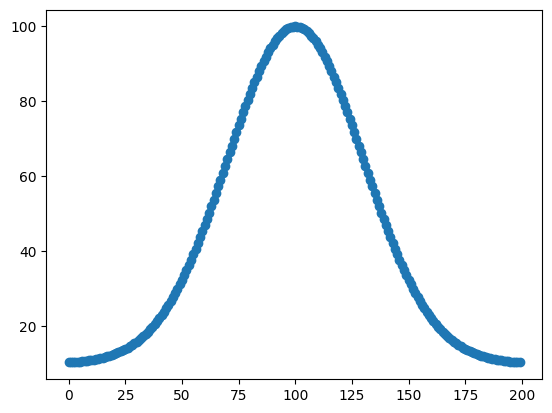

In [ ]:
from math import exp

from matplotlib.pylab import exp

# Gaussian breathe effect lookup calculation
MAX_BRIGHTNESS:float = 10000
MIN_BRIGHTNESS:float = 1000
N_SAMPLES:int = 200
BETA:float = 0.5
GAMMA_BREATHE:float = .15

LUT:list[float] = [0] * N_SAMPLES

def gaussian(index:int, maxB:float, minB:float, nSamples:int, beta:float, gamma:float) -> float:
    brightness:float = 0
    if index < nSamples:
        brightness = minB + (maxB - minB) * exp(-(((index / nSamples) - beta) ** 2 / (2 * gamma**2)))
    return brightness


for i in range(N_SAMPLES):
    LUT[i] = gaussian(i, MAX_BRIGHTNESS, MIN_BRIGHTNESS, N_SAMPLES, BETA, GAMMA_BREATHE)

# Print as a python "list" with only two decimals
print("[", end="")
for i in LUT[:-1]:
    result = round(i,2)
    print(f"{result:.2f}", end=", ")
print(f"{LUT[-1]:.2f}]")

# Print as C array
print("{", end="")
for i in LUT[:-1]:
    print(f"{round(i):.0f}", end=", ")
print(f"{round(LUT[-1]):.0f}}}")

plt.scatter(range(N_SAMPLES), LUT)

# Data Structures

## Data needed to keep track of the effect

* $T_{pwm}$: period of the PWM wave, set by adjusting the TOP value of the timer, as the frequency of the clock is fixed at 38.4MHz (with a prescaler of 1). It's hardcoded in the FW and I can't see a reason right now to change it dynamically.
* $T_{effect}$: period of the effect. This needs to change dynamically.
* waves per sample: number of PWM cycles per sample of the LUT. Changes with $T_{effect}$. Easy to calculate on the fly, but stored as to not do the same division time and time again.
* $n_{samples}$: number of samples on the breathe effect Lookup Table. No reason to change dynamically, so hardcoded.
* current PWM wave: keep track of the number of PWM waves played for a particular sample.
* LUT index: current sample of the LUT being played.

## Breathe Effect display parameters

These set of parameters define the effect to be played. They are all the parameters required to build the LUT. In principle, they should not need to change dynamically as I expect to find the sweet spot through testing. There's a potential for them to be "dynamic" if blending multiple LED strips together with different curves is pleasant, but that would require a different input method (eg. via BLE) or hard-coding a set of effects.

The Gaussian curve is defined by the max and min brightness, the gamma coefficient (width of the pulse), beta coefficient (relative position of the peak) and the size of the lookup table.

## Breathe Effect Control Parameters

These are the parameters that control the playing of a breathe effect.

To control the playing of a breath effect, we will need to know the period of the effect, the current sample to play from the LUT and a counter for the number of PWM waves played for a certain sample. The number of PWM waves to play per sample can be easily calculated from the period of the effect, the period of the PWM and the number of samples of the LUT, but we can keep it at hand as it will be needed often.

## Brightness Control

While implementing the fades during brightness change, I realised that I needed memory per each channel to keep track of the state of things, so it made more sense to integrate it into the LED data structure, so I made a new struct for brightness control related memory. This struct contains the target brightness level for a LED channel, the delta of brightness to increase / decrease the current level on each PWM cycle when we are chasing a new brightness level and a flag used to know when a change of brightness is requested (as it will require a change in delta to get to the new brightness level, from the current one, in the desired amount of time).

## LED data structure

This is the main data structure for a LED Strip effect. I called it just `LED` for shorts.

Keeps track of the current effect being played on the LED Strip, its brightness control data, the period of the PWM signal (can be easily calculated and it's harcoded, so it just could be a `const`, but it's nice to have it accessible) and a breatheControl_t structure that contains the control parameters for the breathe effect.


# Effect Control Loop

The default mode will be fixed brightness. The initialization function for the LED data structure will set all the necessary data to start in this mode.

The main driver will be the Overflow interrupt in the PWM timer. When it triggers, it just sets a flag. If the flag is set, on the main app loop, the `effectControlLoop()` function will be called, or skipped otherwise.

Even if the initial target brightness is set to 0, the overflow interrupt will be triggered, i.e., the effect control function will be called even if the target brightness is 0, as it doesn't depend on the compare event, but on the overflow event, and that event happens once per PWM cycle.

## Fixed Brightness

If the LED channel is set to Fixed Brightness, the effect control loop checks what is the current compare value for the channel, and if it's different than the target value, it will increase / decrease towards it. Instead of just setting the target value (which would make the brightness jump), we will slowly fade towards the target.

We are aiming at changing brightness in ~1s. If the change is big enough, the delta of change will be calculated based on a 1s change. If the change is not big enough, we will increase / decrease with the smalles delta (0.01%) for as long as needed to reach the target level

## Breathe Effect

The brightness values for the breathe effect are generated on the fly by the FW. There's really not a clear reason why this is generated on the fly and the gamma-corrected brightness isn't, other than this LUT is way shorter (200 items right now, and I even took the luxury to do it uint32_t so I didn't have to cast when doing operations with it).

The default parameters are hard-coded, with β being 0.5 (peak at half the period) and γ = 0.15 (relative-ly narrow, dark-favouring peak).

The period is adjusted to change in multiples of the LUT and the period of the PWM wave. This wave, we know we play each level for n PWM waves. For example, with PWM freq of 1KHz and a LUT of 200 samples, the Breathe Effect period increases in 200ms increments (200 * 1ms). That way, if the breathe effect period is 5s, each sample is played for 50 PWM cycles. A counter keeps track of the number of cycles played and increments the sample to play when it's time to do it.

The target brightness level of the Fixed Brightness effect acts as an scaler. If the breathe effect ranges from 10 to 100% and the target brightness is set to 80%, then the breathe effect loops from 80% to 8%. That way we can adjust both its period and it's general brightness, while keeping the relative variation of brightness.

# Button Behaviour

I haven't really done much when it comes to button handling. The code is quite primitive. 

## Button Presses 

The button struct has pointers to two sleeptimers. When a button changes state (pressed to released or released to pressed), an interrupt is triggered that sets them in motion. One of them controls debouncing event and the other checks the integration. 

### Debouncing

Debouncing is handled by the code in `debounce.c`. It's an integrator, which ticks every 5ms. If the button is pressed, the integrator increases, and if it is released, decreases. After the debouncing timer times out (75ms) if the integrator is 0, the button is set as released. If on the contrary is over the target threshold (5) it is considered pressed. If it sits in between, the event was ambiguous and no change in state happens.

If the event was a press, the time of the press is kept to check for a long or short press.

### Long / Short Press

The time of the pressing of a button is stored in the button struct. After a release event, the time of the release is checked agains the time of the press and if it's bigger than the long press delta, it's considered a long press.

## Quad Encoders

They are interrupt-driven. Interrupts are set on falling edge of pin 0. When an interrupt triggers, we check the state of pin 1. If it's set, then it's a CW click, and if it's clear, then it's a CCW one. Easy.

There's no SW debouncing, so the inputs must be debounced by HW.

## Button Actions

### Encoder / Button 0 (Top One)

Pressing the button changes the selected LED channel

Rotating the encoder changes the overall brightness of the LED Channel

### Encoder / Button 1 (Bottom One)

Pressing the button changes the animation for the currenty selected mode.

Rotating the encoder changes the Period of the Breathe Effect.

### Longpress of both buttons

If both buttons are pressed for more than 3s at the same time, the device will enter low power mode. Everything shuts down until a button is pressed again, when the device wakes. LED state is stored in the NVM and restored on startup.

# Sleep

I like the idea of having a button combination that sets the thing to sleep, as a quick way to turn it off. The power savings are going to be minimal, as the board in EM0 draws around 5mA and just the board itself, with the microcontroller held in reset is on 3.21mA. But even if it's just as a way to turn it off and on, is not a bad idea.

I could use EM2 to keep Bluetooth alive, but I'm not worried much about BLE right now, maybe later...

EM4 is the the shut-down level. We can only wake up via a reset, which is not a terrible thing here.

I played a bit with the Power Manager module in SDK v6 and to be fair, I don't really get it. Luckily, EM4 is outside of its scope. Power consumption of the whole board (not just the μC) while in EM4 is around 3mA@3.3V -> 0.01W (from 5.26 with BLE on but LEDs off), I'm sure the transformer leaks more power already.

In any case, it's a nice experiment, and a nice way to shut the thing down while saving some state info into the NVM that can be restored on boot?. Let's do it!